# Sphere

In [ ]:
from algoritmo import new_population, sphere
import random
from utils import crossing, cut, mutation_sub

# Config do experimento
tam_pop = 400
dimensoes = 30
min_val = -100
max_val = 100
geracoes = 1000
taxa_mutacao = 0.01  # 1% de chance para cada gene
taxa_crossing = 0.20 # 20% de chance de cruzamento

# Inicializa a população inicial
new_pop = new_population(tam_pop, dimensoes, min_val, max_val)
geracoes_totais = []

for g in range(geracoes):
    fitness_list = []
    populacao_avaliada = []
    
    # 1. Avaliação: calcula o fitness 
    for individuo in new_pop:
        fit = sphere(individuo)
        fitness_list.append(fit)
        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fit
        })

    # 2. Seleção por torneio
    populacao_selecionada = []
    for _ in range(tam_pop):
        # Sorteia 2 e o menor fitness vence 
        a, b = random.sample(populacao_avaliada, 2)
        vencedor = a if a["fitness"] < b["fitness"] else b
        populacao_selecionada.append(vencedor)
    
    # Salva o melhor fitness desta geração para usar no gráfico
    melhor_da_geracao = min(fitness_list)
    geracoes_totais.append(melhor_da_geracao)
    print(f"Geração {g+1} | Melhor fitness: {melhor_da_geracao:.5f}")

    # 3. Criação da próxima geração 
    new_pop = []
    for i in range(0, len(populacao_selecionada), 2):
        pai1 = populacao_selecionada[i]['individuo']
        pai2 = populacao_selecionada[i+1]['individuo']
        
        # Decide se vai haver cruzamento
        if crossing(taxa_crossing):
            filho1, filho2 = cut(pai1, pai2)
        else:
            # Se não cruzar, cria clones 
            filho1, filho2 = pai1[:], pai2[:]

        # Aplica a mutação por substituição
        filho1 = mutation_sub(filho1, taxa_mutacao, min_val, max_val)
        filho2 = mutation_sub(filho2, taxa_mutacao, min_val, max_val)

        new_pop.append(filho1)
        new_pop.append(filho2)

print("\n--- Resultado final ---")
print(f"Menor valor de sphere encontrado: {min(geracoes_totais)}")

Geração 1 | Melhor fitness: 53065.04438
Geração 2 | Melhor fitness: 54562.37552
Geração 3 | Melhor fitness: 48302.35518
Geração 4 | Melhor fitness: 44240.69585
Geração 5 | Melhor fitness: 40348.13080
Geração 6 | Melhor fitness: 24158.70651
Geração 7 | Melhor fitness: 29636.10447
Geração 8 | Melhor fitness: 29636.10447
Geração 9 | Melhor fitness: 22250.63261
Geração 10 | Melhor fitness: 22250.63261
Geração 11 | Melhor fitness: 15644.42146
Geração 12 | Melhor fitness: 21545.52067
Geração 13 | Melhor fitness: 18932.09446
Geração 14 | Melhor fitness: 15156.43671
Geração 15 | Melhor fitness: 15156.43671
Geração 16 | Melhor fitness: 14579.96631
Geração 17 | Melhor fitness: 13037.51342
Geração 18 | Melhor fitness: 13597.53377
Geração 19 | Melhor fitness: 11663.38554
Geração 20 | Melhor fitness: 10718.69230
Geração 21 | Melhor fitness: 10478.94178
Geração 22 | Melhor fitness: 10227.22188
Geração 23 | Melhor fitness: 8923.76206
Geração 24 | Melhor fitness: 7907.83536
Geração 25 | Melhor fitness

## Gráficos Sphere

### Gráfico de Convergência

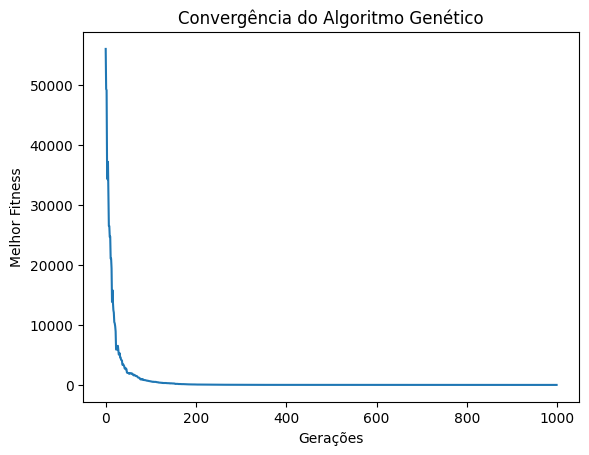

In [589]:
import matplotlib.pyplot as plt

plt.plot(geracoes_totais)

plt.title("Convergência do Algoritmo Genético")
plt.xlabel("Gerações")
plt.ylabel("Melhor Fitness")

plt.show()

### Boxplot

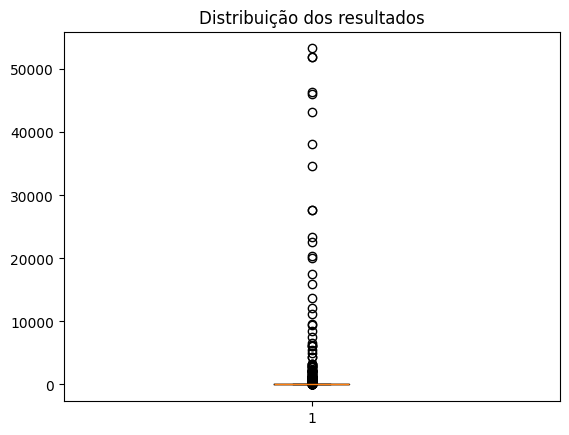

In [592]:
plt.boxplot(geracoes_totais)
plt.title("Distribuição dos resultados")
plt.show()

In [610]:
import plotly.express as px
boxplot = px.box(y=geracoes_totais, title="Boxplot Interativo")
boxplot.show()

# Rastringin




In [ ]:
from algoritmo import rastrigin

# Config do experimento
tam_pop = 450
dimensoes = 30
min_val = -30 
max_val = 30    
geracoes = 1600
taxa_mutacao = 0.01
taxa_crossing = 0.16

# Inicializa a população inicial
new_pop = new_population(tam_pop, dimensoes, min_val, max_val)
geracoes_totais = []

for g in range(geracoes):
    fitness_list = []
    populacao_avaliada = []
    
    # 1. Avaliação: calcula o fitness 
    for individuo in new_pop:
        fit = rastrigin(individuo)
        fitness_list.append(fit)
        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fit
        })

    # 2. Seleção por torneio
    populacao_selecionada = []
    for _ in range(tam_pop):
        # Sorteia 2 e o menor fitness vence 
        a, b = random.sample(populacao_avaliada, 2)
        vencedor = a if a["fitness"] < b["fitness"] else b
        populacao_selecionada.append(vencedor)
    
    # Salva o melhor fitness desta geração
    melhor_da_geracao = min(fitness_list)
    geracoes_totais.append(melhor_da_geracao)
    print(f"Geração {g+1} | Melhor fitness: {melhor_da_geracao:.5f}")

    # 3. Criação da próxima geração 
    new_pop = []
    for i in range(0, len(populacao_selecionada), 2):
        
        pai1 = populacao_selecionada[i]['individuo']
        pai2 = populacao_selecionada[i+1]['individuo']
        
        # Decide se vai haver cruzamento
        if crossing(taxa_crossing):
            filho1, filho2 = cut(pai1, pai2)
        else:
            # Se não cruzar, cria clones 
            filho1, filho2 = pai1[:], pai2[:]

        # Aplica a mutação por substituição 
        filho1 = mutation_sub(filho1, taxa_mutacao, min_val, max_val)
        filho2 = mutation_sub(filho2, taxa_mutacao, min_val, max_val)

        new_pop.append(filho1)
        new_pop.append(filho2)

print("\n--- resultado final ---")
print(f"menor valor de rastrigin encontrado: {min(geracoes_totais)}")

Geração 1 | Melhor fitness: 5685.88901
Geração 2 | Melhor fitness: 5721.40817
Geração 3 | Melhor fitness: 4655.92212
Geração 4 | Melhor fitness: 4827.10637
Geração 5 | Melhor fitness: 4182.12651
Geração 6 | Melhor fitness: 3731.51952
Geração 7 | Melhor fitness: 3709.31688
Geração 8 | Melhor fitness: 3604.26357
Geração 9 | Melhor fitness: 3214.97693
Geração 10 | Melhor fitness: 2919.50548
Geração 11 | Melhor fitness: 2612.77275
Geração 12 | Melhor fitness: 2473.61791
Geração 13 | Melhor fitness: 2213.29751
Geração 14 | Melhor fitness: 1820.27688
Geração 15 | Melhor fitness: 1820.27688
Geração 16 | Melhor fitness: 1535.36690
Geração 17 | Melhor fitness: 1642.69738
Geração 18 | Melhor fitness: 1365.76397
Geração 19 | Melhor fitness: 1277.45920
Geração 20 | Melhor fitness: 1084.40432
Geração 21 | Melhor fitness: 983.75914
Geração 22 | Melhor fitness: 975.86326
Geração 23 | Melhor fitness: 952.79763
Geração 24 | Melhor fitness: 923.89650
Geração 25 | Melhor fitness: 750.67209
Geração 26 | M

## Gráfico de Convergência

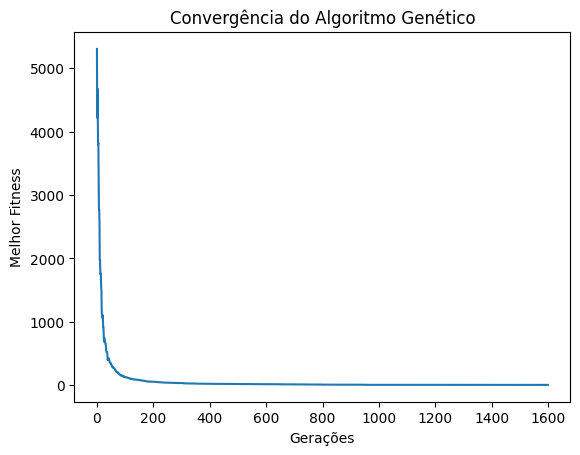

In [612]:
plt.plot(geracoes_totais)

plt.title("Convergência do Algoritmo Genético")
plt.xlabel("Gerações")
plt.ylabel("Melhor Fitness")

plt.show()

## Boxplot

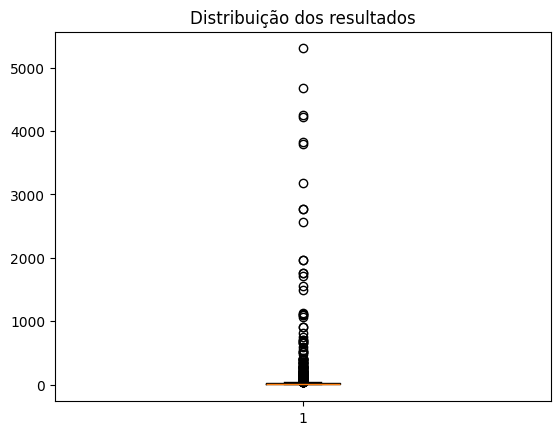

In [613]:
plt.boxplot(geracoes_totais)
plt.title("Distribuição dos resultados")
plt.show()

In [614]:
boxplot = px.box(y=geracoes_totais, title="Boxplot Interativo")
boxplot.show()

# Rosenbrock


In [ ]:
from algoritmo import rosenbrock

# Config do experimento
tam_pop = 50
dimensoes = 30
min_val = -5.12      
max_val = 5.12       
geracoes = 3000
taxa_mutacao = 0.01
taxa_crossing = 0.15

# Inicializa a população inicial
new_pop = new_population(tam_pop, dimensoes, min_val, max_val)
geracoes_totais = []

for g in range(geracoes):
    fitness_list = []
    populacao_avaliada = []
    
    # 1. Avaliação: calcula o fitness 
    for individuo in new_pop:
        fit = rosenbrock(individuo)
        fitness_list.append(fit)
        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fit
        })

    # 2. Seleção por torneio
    populacao_selecionada = []
    for _ in range(tam_pop):
        a, b = random.sample(populacao_avaliada, 2)
        vencedor = a if a["fitness"] < b["fitness"] else b
        populacao_selecionada.append(vencedor)
    
    # Salva o melhor fitness desta geração
    melhor_da_geracao = min(fitness_list)
    geracoes_totais.append(melhor_da_geracao)
    print(f"Geração {g+1} | Melhor fitness: {melhor_da_geracao:.5f}")

    # 3. Criação da próxima geração 
    new_pop = []
    for i in range(0, len(populacao_selecionada), 2):
        pai1 = populacao_selecionada[i]['individuo']
        pai2 = populacao_selecionada[i+1]['individuo']
        
        # Decide se vai haver cruzamento
        if crossing(taxa_crossing):
            filho1, filho2 = cut(pai1, pai2)
        else:
            filho1, filho2 = pai1[:], pai2[:]

        # Aplica a mutação por substituição 
        filho1 = mutation_sub(filho1, taxa_mutacao, min_val, max_val)
        filho2 = mutation_sub(filho2, taxa_mutacao, min_val, max_val)

        new_pop.append(filho1)
        new_pop.append(filho2)

print("\n--- resultado final ---")
print(f"menor valor de rosenbrock encontrado: {min(geracoes_totais)}")

Geração 1 | Melhor fitness: 209621.20503
Geração 2 | Melhor fitness: 159780.41720
Geração 3 | Melhor fitness: 121492.75916
Geração 4 | Melhor fitness: 115390.31560
Geração 5 | Melhor fitness: 56236.77371
Geração 6 | Melhor fitness: 54152.40833
Geração 7 | Melhor fitness: 52328.46837
Geração 8 | Melhor fitness: 44319.44623
Geração 9 | Melhor fitness: 46727.79660
Geração 10 | Melhor fitness: 44544.33927
Geração 11 | Melhor fitness: 39624.08423
Geração 12 | Melhor fitness: 35504.88466
Geração 13 | Melhor fitness: 35504.88466
Geração 14 | Melhor fitness: 34844.89045
Geração 15 | Melhor fitness: 30974.14199
Geração 16 | Melhor fitness: 29882.78976
Geração 17 | Melhor fitness: 26448.95900
Geração 18 | Melhor fitness: 18550.43888
Geração 19 | Melhor fitness: 18705.58466
Geração 20 | Melhor fitness: 18877.70581
Geração 21 | Melhor fitness: 17859.90367
Geração 22 | Melhor fitness: 15941.53973
Geração 23 | Melhor fitness: 15418.14933
Geração 24 | Melhor fitness: 15418.14933
Geração 25 | Melhor f

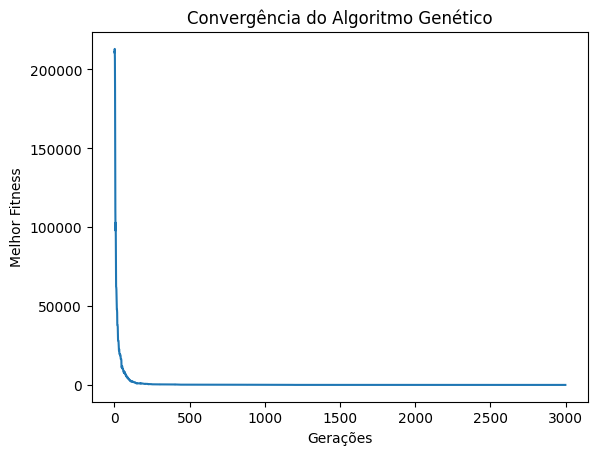

In [616]:
plt.plot(geracoes_totais)

plt.title("Convergência do Algoritmo Genético")
plt.xlabel("Gerações")
plt.ylabel("Melhor Fitness")

plt.show()

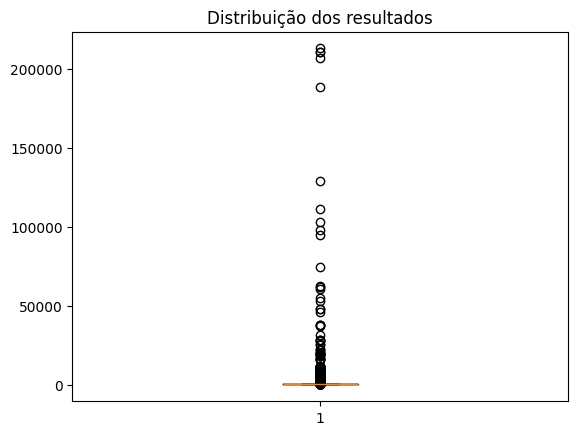

In [617]:
plt.boxplot(geracoes_totais)
plt.title("Distribuição dos resultados")
plt.show()

In [618]:
boxplot = px.box(y=geracoes_totais, title="Boxplot Interativo")
boxplot.show()

# Sphere (Roleta)

In [15]:
from algoritmo import new_population, sphere, selecao_roleta
from utils import crossing, cut, mutation_sub

DIMENSOES = 30
LIMITES = (-100, 100)  # Min e Max para Sphere
TAM_POP = 400
GERACOES = 3000
TAXA_MUTACAO = 0.01
TAXA_CROSSING = 0.16

# 1. Inicializa a população inicial
new_pop = new_population(TAM_POP, DIMENSOES, LIMITES[0], LIMITES[1])
geracoes_totais = []

for g in range(GERACOES):
    fitness_list = []
    populacao_avaliada = []
    
    # 2. Avaliação: calcula o fitness
    for individuo in new_pop:
        fit = sphere(individuo)
        fitness_list.append(fit)
        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fit
        })

    # 3. Seleção por roleta
    populacao_selecionada = selecao_roleta(populacao_avaliada, TAM_POP)
    
    # Salva e imprime o melhor fitness desta geração
    melhor_da_geracao = min(fitness_list)
    geracoes_totais.append(melhor_da_geracao)
    
    # Imprime todas as gerações
    print(f"Geração {g+1} | Melhor fitness: {melhor_da_geracao:.5f}")

    # 4. Criação da próxima geração (Cruzamento + Mutação)
    proxima_geracao = []
    for i in range(0, len(populacao_selecionada), 2):
        pai1 = populacao_selecionada[i]['individuo']
        pai2 = populacao_selecionada[i+1]['individuo']
        
        # Cruzamento
        if crossing(TAXA_CROSSING):
            filho1, filho2 = cut(pai1, pai2)
        else:
            filho1, filho2 = pai1[:], pai2[:]

        # Mutação
        filho1 = mutation_sub(filho1, TAXA_MUTACAO, LIMITES[0], LIMITES[1])
        filho2 = mutation_sub(filho2, TAXA_MUTACAO, LIMITES[0], LIMITES[1])

        proxima_geracao.append(filho1)
        proxima_geracao.append(filho2)
    
    new_pop = proxima_geracao

print("\n--- Resultado final ---")
print(f"Menor valor de sphere encontrado: {min(geracoes_totais)}")

Geração 1 | Melhor fitness: 61379.26282
Geração 2 | Melhor fitness: 59648.52154
Geração 3 | Melhor fitness: 56048.09011
Geração 4 | Melhor fitness: 55131.76738
Geração 5 | Melhor fitness: 49165.38605
Geração 6 | Melhor fitness: 49473.06106
Geração 7 | Melhor fitness: 49740.62714
Geração 8 | Melhor fitness: 44459.31679
Geração 9 | Melhor fitness: 42944.32052
Geração 10 | Melhor fitness: 39191.65938
Geração 11 | Melhor fitness: 31024.94902
Geração 12 | Melhor fitness: 28509.84701
Geração 13 | Melhor fitness: 28502.18973
Geração 14 | Melhor fitness: 28509.84701
Geração 15 | Melhor fitness: 28509.84701
Geração 16 | Melhor fitness: 27255.72558
Geração 17 | Melhor fitness: 22969.47722
Geração 18 | Melhor fitness: 23187.22082
Geração 19 | Melhor fitness: 23374.97345
Geração 20 | Melhor fitness: 24255.82236
Geração 21 | Melhor fitness: 21014.48804
Geração 22 | Melhor fitness: 17821.80045
Geração 23 | Melhor fitness: 20483.12558
Geração 24 | Melhor fitness: 20012.13387
Geração 25 | Melhor fitne

# Rastringin (Roleta)

In [16]:
from algoritmo import new_population, rastrigin, selecao_roleta
from utils import crossing, cut, mutation_sub


DIMENSOES = 30
LIMITES = (-30, 30)  # Min e Max específicos para Rastrigin
TAM_POP = 400
GERACOES = 3000
TAXA_MUTACAO = 0.01
TAXA_CROSSING = 0.16

# 1. Inicializa a população inicial
new_pop = new_population(TAM_POP, DIMENSOES, LIMITES[0], LIMITES[1])
geracoes_totais = []

for g in range(GERACOES):
    fitness_list = []
    populacao_avaliada = []
    
    # 2. Avaliação: calcula o fitness
    for individuo in new_pop:
        fit = rastrigin(individuo)
        fitness_list.append(fit)
        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fit
        })

    # 3. Seleção por Roleta
    populacao_selecionada = selecao_roleta(populacao_avaliada, TAM_POP)
    
    # Salva e imprime o melhor fitness desta geração
    melhor_da_geracao = min(fitness_list)
    geracoes_totais.append(melhor_da_geracao)
    
    # Imprime todas as gerações sem pular
    print(f"Geração {g+1} | Melhor fitness: {melhor_da_geracao:.5f}")

    # 4. Criação da próxima geração 
    proxima_geracao = []
    for i in range(0, len(populacao_selecionada), 2):
        pai1 = populacao_selecionada[i]['individuo']
        pai2 = populacao_selecionada[i+1]['individuo']
        
        # Cruzamento
        if crossing(TAXA_CROSSING):
            filho1, filho2 = cut(pai1, pai2)
        else:
            filho1, filho2 = pai1[:], pai2[:]

        # Mutação 
        filho1 = mutation_sub(filho1, TAXA_MUTACAO, LIMITES[0], LIMITES[1])
        filho2 = mutation_sub(filho2, TAXA_MUTACAO, LIMITES[0], LIMITES[1])

        proxima_geracao.append(filho1)
        proxima_geracao.append(filho2)
    
    new_pop = proxima_geracao

print("\n--- Resultado final ---")
print(f"Menor valor de rastrigin encontrado: {min(geracoes_totais)}")

Geração 1 | Melhor fitness: 4875.34541
Geração 2 | Melhor fitness: 4875.34541
Geração 3 | Melhor fitness: 4999.78319
Geração 4 | Melhor fitness: 4958.47555
Geração 5 | Melhor fitness: 4827.25318
Geração 6 | Melhor fitness: 4200.54084
Geração 7 | Melhor fitness: 4200.54084
Geração 8 | Melhor fitness: 4035.91539
Geração 9 | Melhor fitness: 3444.84869
Geração 10 | Melhor fitness: 3213.08566
Geração 11 | Melhor fitness: 3354.70675
Geração 12 | Melhor fitness: 3142.96969
Geração 13 | Melhor fitness: 3087.22381
Geração 14 | Melhor fitness: 3087.22381
Geração 15 | Melhor fitness: 2725.32354
Geração 16 | Melhor fitness: 2657.36490
Geração 17 | Melhor fitness: 2471.55386
Geração 18 | Melhor fitness: 2553.36316
Geração 19 | Melhor fitness: 2351.23722
Geração 20 | Melhor fitness: 2083.81125
Geração 21 | Melhor fitness: 2254.32919
Geração 22 | Melhor fitness: 2230.55825
Geração 23 | Melhor fitness: 1818.34952
Geração 24 | Melhor fitness: 1742.75477
Geração 25 | Melhor fitness: 1721.23658
Geração 2

# Rosenbrock (Roleta)

In [12]:
from algoritmo import new_population, rosenbrock, selecao_roleta
from utils import crossing, cut, mutation_sub


DIMENSOES = 30
LIMITES = (-5.12, 5.12)  
TAM_POP = 400             
GERACOES = 3000          
TAXA_MUTACAO = 0.01
TAXA_CROSSING = 0.16

# 1. Inicializa a população inicial
new_pop = new_population(TAM_POP, DIMENSOES, LIMITES[0], LIMITES[1])
geracoes_totais = []

for g in range(GERACOES):
    fitness_list = []
    populacao_avaliada = []
    
    # 2. Avaliação: calcula o fitness 
    for individuo in new_pop:
        fit = rosenbrock(individuo)
        fitness_list.append(fit)
        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fit
        })

    # 3. Seleção por Roleta
    populacao_selecionada = selecao_roleta(populacao_avaliada, TAM_POP)
    
    # Salva e imprime o melhor fitness desta geração
    melhor_da_geracao = min(fitness_list)
    geracoes_totais.append(melhor_da_geracao)
    
    # Imprime todas as gerações
    print(f"Geração {g+1} | Melhor fitness: {melhor_da_geracao:.5f}")

    # 4. Criação da próxima geração
    proxima_geracao = []
    for i in range(0, len(populacao_selecionada), 2):
        pai1 = populacao_selecionada[i]['individuo']
        pai2 = populacao_selecionada[i+1]['individuo']
        
        if crossing(TAXA_CROSSING):
            filho1, filho2 = cut(pai1, pai2)
        else:
            filho1, filho2 = pai1[:], pai2[:]

        # Mutação (dentro dos limites de -5.12 a 5.12)
        filho1 = mutation_sub(filho1, TAXA_MUTACAO, LIMITES[0], LIMITES[1])
        filho2 = mutation_sub(filho2, TAXA_MUTACAO, LIMITES[0], LIMITES[1])

        proxima_geracao.append(filho1)
        proxima_geracao.append(filho2)
    
    new_pop = proxima_geracao

print("\n--- Resultado final ---")
print(f"Menor valor de rosenbrock encontrado: {min(geracoes_totais)}")

Geração 1 | Melhor fitness: 135308.95768
Geração 2 | Melhor fitness: 110494.84514
Geração 3 | Melhor fitness: 111797.19432
Geração 4 | Melhor fitness: 136705.10568
Geração 5 | Melhor fitness: 137852.34843
Geração 6 | Melhor fitness: 132699.41006
Geração 7 | Melhor fitness: 125602.10195
Geração 8 | Melhor fitness: 105271.33019
Geração 9 | Melhor fitness: 89702.39080
Geração 10 | Melhor fitness: 105167.29501
Geração 11 | Melhor fitness: 107084.40308
Geração 12 | Melhor fitness: 65250.73590
Geração 13 | Melhor fitness: 64901.39693
Geração 14 | Melhor fitness: 52683.85495
Geração 15 | Melhor fitness: 62778.99390
Geração 16 | Melhor fitness: 53389.58299
Geração 17 | Melhor fitness: 58658.32520
Geração 18 | Melhor fitness: 39570.70918
Geração 19 | Melhor fitness: 40408.81502
Geração 20 | Melhor fitness: 46048.91112
Geração 21 | Melhor fitness: 32881.82806
Geração 22 | Melhor fitness: 35978.54969
Geração 23 | Melhor fitness: 37264.03267
Geração 24 | Melhor fitness: 30766.12664
Geração 25 | Me